# Notebook 06 — Two-Step Optimal Estimation Retrieval

Demonstrates end-to-end retrieval using `bio_optics.inversion.oe_engine`.

**Two-step workflow** (motivated by the near-zero water ↔ surface cross-block from NB05 §8):

| Step | Model | Free params | Prior strength |
|------|-------|-------------|----------------|
| 1 | `albert_mobley_3C_jax` (water + surface) | C_0, C_Y, C_X, C_Mie, zB + g_dsr, g_dsa, d_r | loose surface, moderate water |
| 2 | `albert_mobley_jax` (water only) | C_0, C_Y, C_X, C_Mie, zB | tighter water |

**Reference**: Rodgers, C.D. (2000): *Inverse Methods for Atmospheric Sounding*. World Scientific.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from lmfit import Parameters

from bio_optics.water.reflectance import albert_mobley_jax
from bio_optics.coupled_models import albert_mobley_3C_jax
from bio_optics.inversion import oe_engine

jax.config.update("jax_enable_x64", True)

# --- sensor / scene configuration -------------------------------------------
wavelengths = np.arange(420, 800, 5, dtype=float)   # 76 bands, 5 nm step
noise_std   = 5e-4                                   # sr⁻¹, uniform per band
np.random.seed(42)

# --- precompute spectral lookup tables (runs once, outside JIT) -------------
pre_3C = albert_mobley_3C_jax.precompute(wavelengths, theta_sun=np.radians(30))
pre_w  = albert_mobley_jax.precompute(wavelengths)

## 1 — Simulate a noisy observation

We define a set of **true** bio-optical and surface parameters, simulate a clean $R_{rs}$ with the 3C model, then add white Gaussian noise with $\sigma_\varepsilon = 5\times10^{-4}\,\text{sr}^{-1}$.

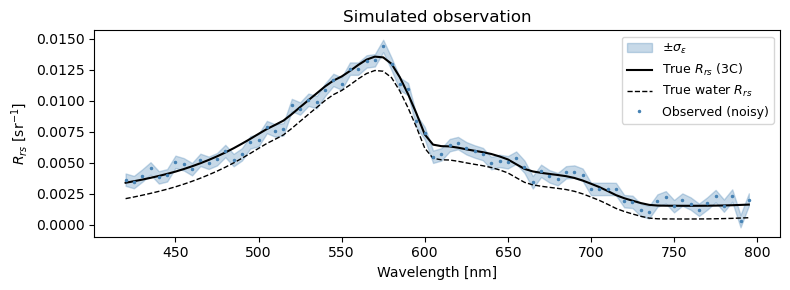

In [2]:
def make_params(base_values=None):
    """
    Build a lmfit Parameters object with all parameters required by
    albert_mobley_jax._forward_core.  All parameters start as vary=False;
    the caller sets vary=True for free parameters.

    Parameters that are only used in precompute() (fresh, b_X_norm_factor)
    are intentionally excluded — they are baked into the precomputed arrays.
    """
    p = Parameters()
    # Geometry
    p.add('theta_sun',  value=np.radians(30), vary=False)
    p.add('theta_view', value=np.radians(2),  vary=False)
    p.add('n1',         value=1.0,            vary=False)
    p.add('n2',         value=1.33,           vary=False)
    # Phytoplankton concentrations [mg m⁻³]
    p.add('C_0',  value=1.0,  vary=False, min=0.0, max=50.0)
    p.add('C_1',  value=0.0,  vary=False)
    p.add('C_2',  value=0.0,  vary=False)
    p.add('C_3',  value=0.0,  vary=False)
    p.add('C_4',  value=0.0,  vary=False)
    p.add('C_5',  value=0.0,  vary=False)
    # Water quality
    p.add('C_Y',   value=0.5,   vary=False, min=0.0, max=10.0)    # CDOM [m⁻¹]
    p.add('C_X',   value=0.0,   vary=False, min=0.0, max=100.0)   # SPM type I [g m⁻³]
    p.add('C_Mie', value=1.0,   vary=False, min=0.0, max=50.0)    # SPM Mie [g m⁻³]
    p.add('zB',    value=5.0,   vary=False, min=0.0, max=200.0)   # bottom depth [m]
    # Bottom substrate fractions and brightnesses
    p.add('f_0',  value=0.5,       vary=False)
    p.add('f_1',  value=0.5,       vary=False)
    p.add('f_2',  value=0.0,       vary=False)
    p.add('f_3',  value=0.0,       vary=False)
    p.add('f_4',  value=0.0,       vary=False)
    p.add('f_5',  value=0.0,       vary=False)
    p.add('B_0',  value=1/np.pi,   vary=False)
    p.add('B_1',  value=1/np.pi,   vary=False)
    p.add('B_2',  value=1/np.pi,   vary=False)
    p.add('B_3',  value=1/np.pi,   vary=False)
    p.add('B_4',  value=1/np.pi,   vary=False)
    p.add('B_5',  value=1/np.pi,   vary=False)
    # IOP spectral parameters (fixed at literature values)
    p.add('bb_phy_spec',         value=0.001,   vary=False)   # [m² mg⁻¹]
    p.add('bb_Mie_spec',         value=0.0042,  vary=False)   # [m² g⁻¹]
    p.add('bb_X_spec',           value=0.0086,  vary=False)   # [m² g⁻¹]
    p.add('S',                   value=0.014,   vary=False)   # CDOM slope [nm⁻¹]
    p.add('S_NAP',               value=0.011,   vary=False)   # NAP slope [nm⁻¹]
    p.add('K',                   value=0.0,     vary=False)
    p.add('lambda_0',            value=440.0,   vary=False)   # reference wavelength [nm]
    p.add('lambda_S',            value=500.0,   vary=False)   # Mie reference wavelength [nm]
    p.add('n',                   value=0.0,     vary=False)   # Junge exponent
    p.add('a_NAP_spec_lambda_0', value=0.041,   vary=False)   # [m² g⁻¹]
    p.add('T_W',                 value=20.0,    vary=False)   # water temperature [°C]
    p.add('T_W_0',               value=20.0,    vary=False)   # reference temperature [°C]
    p.add('kappa_0',             value=1.0546,  vary=False)
    # Override with caller-supplied values
    if base_values is not None:
        for k, v in base_values.items():
            if k in p:
                p[k].value = v
    return p


# --- ground truth (used only for simulation, not for inversion) -------------
truth = dict(
    C_0=1.5, C_Y=0.4, C_X=3.0, C_Mie=0.8, zB=6.0,   # water quality
    g_dsr=0.06, g_dsa=0.015, d_r=0.001,               # surface glint
)

# Build the true parameter set (3C model)
params_true = make_params(truth)
params_true.add('fd_d',   value=1.0,           vary=False)
params_true.add('fd_s',   value=1.0,           vary=False)
params_true.add('g_dd',   value=0.0,           vary=False)
params_true.add('g_dsr',  value=truth['g_dsr'], vary=False)
params_true.add('g_dsa',  value=truth['g_dsa'], vary=False)
params_true.add('d_r',    value=truth['d_r'],   vary=False)
params_true.add('offset', value=0.0,           vary=False)

Rrs_true       = np.array(albert_mobley_3C_jax.forward(params_true, pre_3C))
Rrs_water_true = np.array(albert_mobley_jax.forward(params_true, pre_w))   # water-only (no glint)
Rrs_obs        = Rrs_true + noise_std * np.random.randn(len(wavelengths))

fig, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(wavelengths, Rrs_obs - noise_std, Rrs_obs + noise_std,
                alpha=0.3, color='steelblue', label=r'$\pm\sigma_\varepsilon$')
ax.plot(wavelengths, Rrs_true, 'k-', lw=1.5, label='True $R_{rs}$ (3C)')
ax.plot(wavelengths, Rrs_water_true, 'k--', lw=1.0, label='True water $R_{rs}$')
ax.plot(wavelengths, Rrs_obs,  '.', ms=3, color='steelblue', label='Observed (noisy)')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Simulated observation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2 — Step 1: Surface correction (joint 3C fit)

Fit the full coupled model with **loose priors** on surface glint parameters.
Prior means are set to typical/neutral values; the spectrum drives the solution.

Free parameters: C_0, C_Y, C_X, C_Mie, zB (water) + g_dsr, g_dsa, d_r (surface)  
Fixed: g_dd = 0 (degenerate with d_r, as shown by R = −1.00 in NB05 §8)

In [3]:
# --- Step 1 parameter object (prior means = starting values) ----------------
params_s1 = make_params()   # water params at prior means
# Surface params
params_s1.add('fd_d',   value=1.0,  vary=False)
params_s1.add('fd_s',   value=1.0,  vary=False)
params_s1.add('g_dd',   value=0.0,  vary=True)   # fixed: degenerate with d_r
params_s1.add('g_dsr',  value=0.0,  vary=True)    # free: Rayleigh sky glint [sr⁻¹]
params_s1.add('g_dsa',  value=0.0,  vary=True)    # free: aerosol sky glint  [sr⁻¹]
params_s1.add('d_r',    value=0.0,  vary=False)    # free: diffuse residual   [sr⁻¹]
params_s1.add('offset', value=0.0,  vary=False)
# Mark water quality params as free
for name in ['C_0', 'C_Y', 'C_Mie', 'zB']:
    params_s1[name].vary = True

# Prior standard deviations
sigma_a_s1 = dict(
    C_0=2.0, C_Y=1.0, C_Mie=5.0, zB=10.0,   # moderate water priors
    g_dd=0.1, g_dsr=0.15, g_dsa=0.05, d_r=0.002,                   # loose surface priors
)

# Build forward function for the 3C model
all_names_3C = list(params_s1.keys())
f_vec_3C = albert_mobley_3C_jax.make_forward_vec(all_names_3C, pre_3C)

# --- Run Step 1 inversion ---------------------------------------------------
result_s1, names_s1, log_mask_s1 = oe_engine.invert(
    params_s1, Rrs_obs, f_vec_3C, noise_std, sigma_a_s1, n_iter=15
)

print(f'Step 1 complete — DFS: {float(result_s1.dfs):.2f} / {len(names_s1)}')
print(f'               chi²: {float(result_s1.chi2):.4f}  (expect ~1)')
print()
print(f'{"Parameter":<10}  {"Prior":>8}  {"Retrieved":>10}  {"Truth":>8}  {"σ̂":>8}')
print('-' * 55)
for i, name in enumerate(names_s1):
    prior = float(params_s1[name].value)
    retr  = float(result_s1.x_hat[i])
    tr    = truth.get(name, prior)   # truth if defined, else prior
    sig   = float(jnp.sqrt(result_s1.S_hat[i, i]))
    print(f'{name:<10}  {prior:>8.4f}  {retr:>10.4f}  {tr:>8.4f}  {sig:>8.4f}')

Step 1 complete — DFS: 5.29 / 7
               chi²: 0.8288  (expect ~1)

Parameter      Prior   Retrieved     Truth        σ̂
-------------------------------------------------------
C_0           1.0000      1.2947    1.5000    1.2403
C_Y           0.5000      0.3042    0.4000    0.0424
C_Mie         1.0000      6.2709    0.8000    0.4393
zB            5.0000      5.5795    6.0000    0.3301
g_dd          0.0000      0.0674    0.0000    0.0118
g_dsr         0.0000      0.2115    0.0600    0.0873
g_dsa         0.0000      0.0181    0.0150    0.0490


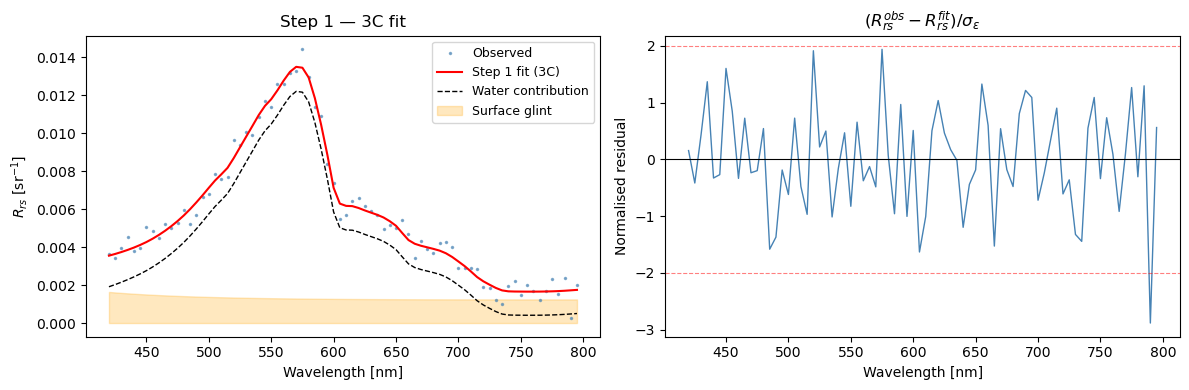

In [4]:
# --- Reconstruct full parameter dict from Step 1 result ---------------------
p_hat_s1 = {n: float(params_s1[n].value) for n in all_names_3C}  # start from fixed vals
for n, v in zip(names_s1, np.array(result_s1.x_hat)):
    p_hat_s1[n] = float(v)

Rrs_fit_3C = np.array(albert_mobley_3C_jax.forward(p_hat_s1, pre_3C))
Rrs_water  = np.array(albert_mobley_jax.forward(p_hat_s1, pre_3C))   # water-only at Step 1 solution
Rrs_glint  = Rrs_fit_3C - Rrs_water

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(wavelengths, Rrs_obs,     '.', ms=3, color='steelblue', alpha=0.6, label='Observed')
ax.plot(wavelengths, Rrs_fit_3C,  'r-',   lw=1.5, label='Step 1 fit (3C)')
ax.plot(wavelengths, Rrs_water,   'k--',  lw=1.0, label='Water contribution')
ax.fill_between(wavelengths, 0, Rrs_glint, alpha=0.25, color='orange', label='Surface glint')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Step 1 — 3C fit')
ax.legend(fontsize=9)

ax = axes[1]
residual_s1 = (Rrs_obs - Rrs_fit_3C) / noise_std
ax.plot(wavelengths, residual_s1, color='steelblue', lw=1)
ax.axhline(0,   color='k', lw=0.8)
ax.axhline( 2,  color='r', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-2,  color='r', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Normalised residual')
ax.set_title(r'$(R_{rs}^{obs} - R_{rs}^{fit}) / \sigma_\varepsilon$')

plt.tight_layout()
plt.show()

## 3 — Step 2: Water quality retrieval on glint-corrected spectrum

Subtract the fitted surface contribution and re-invert with the water-only model.
The corrected spectrum is treated as the new observation:

$$R_{rs}^{\text{corr}} = R_{rs}^{\text{obs}} - \hat{R}_{rs}^{\text{surf}}$$

Tighter priors on the water quality parameters can now be applied.

In [5]:
Rrs_corrected = Rrs_obs - Rrs_glint

# --- Step 2 parameter object ------------------------------------------------
params_s2 = make_params()   # fresh params; prior means same as Step 1
for name in ['C_0', 'C_Y', 'C_Mie', 'zB']:
    params_s2[name].vary = True

# Slightly tighter water priors for Step 2
sigma_a_s2 = dict(C_0=2.0, C_Y=1.0, C_X=10.0, C_Mie=5.0, zB=10.0)

all_names_w = list(params_s2.keys())
f_vec_w = albert_mobley_jax.make_forward_vec(all_names_w, pre_w)

# --- Run Step 2 inversion ---------------------------------------------------
result_s2, names_s2, log_mask_s2 = oe_engine.invert(
    params_s2, Rrs_corrected, f_vec_w, noise_std, sigma_a_s2, n_iter=15
)

print(f'Step 2 complete — DFS: {float(result_s2.dfs):.2f} / {len(names_s2)}')
print(f'               chi²: {float(result_s2.chi2):.4f}  (expect ~1)')
print()
print(f'{"Parameter":<10}  {"Prior":>8}  {"Step 1":>9}  {"Step 2":>9}  {"Truth":>8}  {"σ̂":>8}')
print('-' * 65)
x_hat_s1_dict = dict(zip(names_s1, np.array(result_s1.x_hat)))
for i, name in enumerate(names_s2):
    prior = float(params_s2[name].value)
    s1    = x_hat_s1_dict.get(name, prior)
    s2    = float(result_s2.x_hat[i])
    tr    = truth.get(name, prior)
    sig   = float(jnp.sqrt(result_s2.S_hat[i, i]))
    print(f'{name:<10}  {prior:>8.4f}  {s1:>9.4f}  {s2:>9.4f}  {tr:>8.4f}  {sig:>8.4f}')

Step 2 complete — DFS: 3.66 / 4
               chi²: 0.8288  (expect ~1)

Parameter      Prior     Step 1     Step 2     Truth        σ̂
-----------------------------------------------------------------
C_0           1.0000     1.2947     1.2947    1.5000    1.1639
C_Y           0.5000     0.3042     0.3042    0.4000    0.0297
C_Mie         1.0000     6.2709     6.2709    0.8000    0.2858
zB            5.0000     5.5795     5.5795    6.0000    0.3289


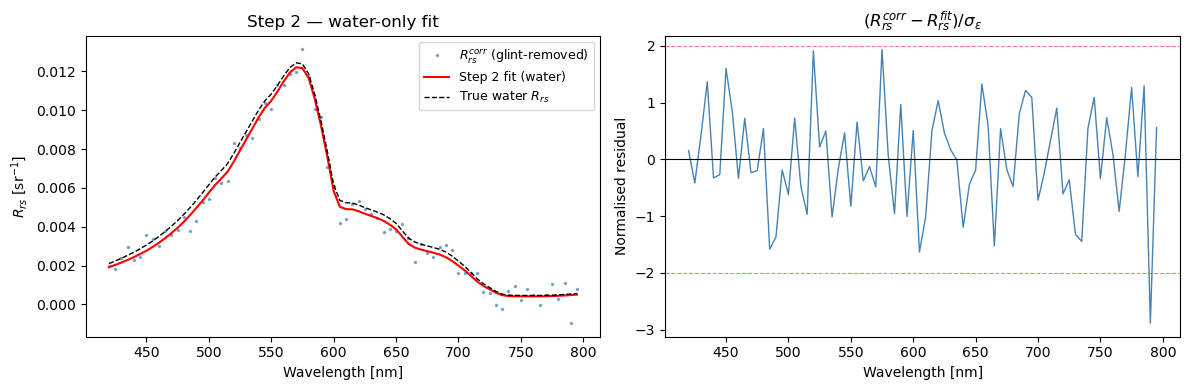

In [6]:
# --- Reconstruct Step 2 fit -------------------------------------------------
p_hat_s2 = {n: float(params_s2[n].value) for n in all_names_w}
for n, v in zip(names_s2, np.array(result_s2.x_hat)):
    p_hat_s2[n] = float(v)

Rrs_fit_s2 = np.array(albert_mobley_jax.forward(p_hat_s2, pre_w))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(wavelengths, Rrs_corrected, '.', ms=3, color='steelblue', alpha=0.6,
        label=r'$R_{rs}^{corr}$ (glint-removed)')
ax.plot(wavelengths, Rrs_fit_s2,    'r-',  lw=1.5, label='Step 2 fit (water)')
ax.plot(wavelengths, Rrs_water_true,'k--', lw=1.0, label='True water $R_{rs}$')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Step 2 — water-only fit')
ax.legend(fontsize=9)

ax = axes[1]
residual_s2 = (Rrs_corrected - Rrs_fit_s2) / noise_std
ax.plot(wavelengths, residual_s2, color='steelblue', lw=1)
ax.axhline(0,  color='k', lw=0.8)
ax.axhline( 2, color='r', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-2, color='r', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Normalised residual')
ax.set_title(r'$(R_{rs}^{corr} - R_{rs}^{fit}) / \sigma_\varepsilon$')

plt.tight_layout()
plt.show()

## 4 — Retrieval diagnostics

Averaging kernel diagonal $A_{ii}$ and posterior standard deviations $\hat{\sigma}_i = \sqrt{\hat{S}_{ii}}$ for Step 2.

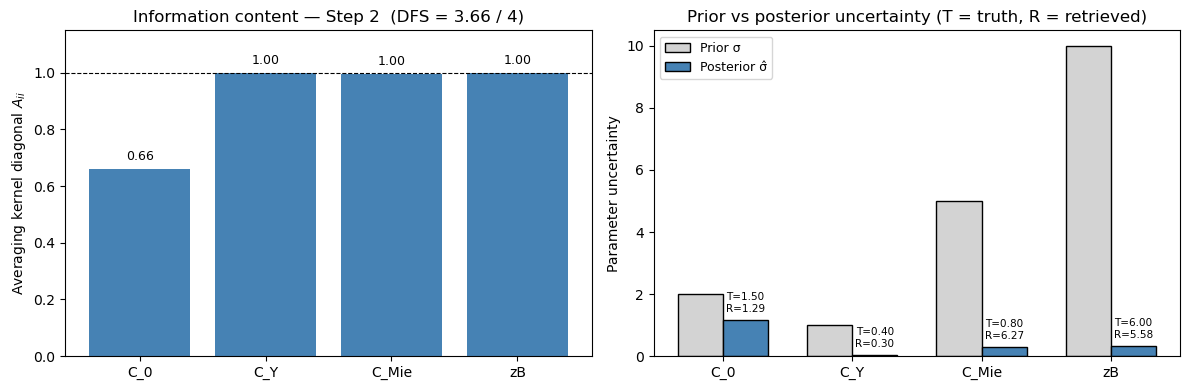


DFS    = 3.66 / 4
H_info = 12.9610 nats
chi²   = 0.8288


In [7]:
sigma_post_s2 = np.sqrt(np.diag(np.array(result_s2.S_hat)))
sigma_prior_s2 = np.array([sigma_a_s2[n] for n in names_s2])
A_diag_s2 = np.diag(np.array(result_s2.A))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Averaging kernel -------------------------------------------------------
ax = axes[0]
bars = ax.bar(names_s2, A_diag_s2, color='steelblue')
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_ylim(0, 1.15)
ax.set_ylabel(r'Averaging kernel diagonal $A_{ii}$')
ax.set_title(f'Information content — Step 2  (DFS = {float(result_s2.dfs):.2f} / {len(names_s2)})')
for bar, val in zip(bars, A_diag_s2):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)

# --- Prior vs posterior uncertainty -----------------------------------------
ax = axes[1]
x = np.arange(len(names_s2))
w = 0.35
ax.bar(x - w/2, sigma_prior_s2, w, label='Prior σ',    color='lightgray', edgecolor='k')
ax.bar(x + w/2, sigma_post_s2,  w, label='Posterior σ̂', color='steelblue',  edgecolor='k')

# Mark truth vs retrieved
for i, name in enumerate(names_s2):
    retr = float(result_s2.x_hat[i])
    tr   = truth.get(name, float(params_s2[name].value))
    ax.annotate(f'T={tr:.2f}\nR={retr:.2f}',
                xy=(i + w/2, sigma_post_s2[i]),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(names_s2)
ax.set_ylabel('Parameter uncertainty')
ax.set_title('Prior vs posterior uncertainty (T = truth, R = retrieved)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nDFS    = {float(result_s2.dfs):.2f} / {len(names_s2)}')
print(f'H_info = {float(result_s2.H_info):.4f} nats')
print(f'chi²   = {float(result_s2.chi2):.4f}')

## 5 — Propagated spectral uncertainty and final parameter table

The posterior covariance of the *spectrum* is obtained by propagating $\hat{S}$ through the Jacobian at the solution:

$$\text{Cov}(\hat{y}) = J\,\hat{S}\,J^\top \qquad \Rightarrow \qquad \hat{\sigma}_y(\lambda) = \sqrt{\left[J\,\hat{S}\,J^\top\right]_{\lambda\lambda}}$$

This gives the per-wavelength uncertainty due to **parameter uncertainty alone** (not measurement noise).

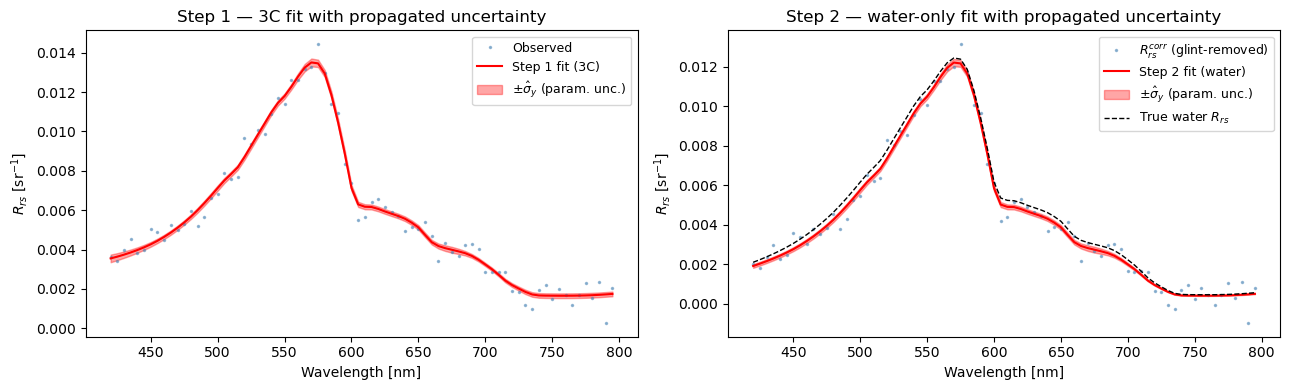

Step 1 — surface + water parameters
Param        Prior μ   Retrieved     Truth        σ̂    σ̂/σ_a    A_ii
────────────────────────────────────────────────────────────────────────
C_0           1.0000      1.2947    1.5000    1.2403     0.620   0.615
C_Y           0.5000      0.3042    0.4000    0.0424     0.042   0.998
C_Mie         1.0000      6.2709    0.8000    0.4393     0.088   0.992
zB            5.0000      5.5795    6.0000    0.3301     0.033   0.999
g_dd          0.0000      0.0674    0.0000    0.0118     0.118   0.986
g_dsr         0.0000      0.2115    0.0600    0.0873     0.582   0.661
g_dsa         0.0000      0.0181    0.0150    0.0490     0.979   0.041

Step 2 — water quality parameters
Param        Prior μ   Retrieved     Truth        σ̂    σ̂/σ_a    A_ii
────────────────────────────────────────────────────────────────────────
C_0           1.0000      1.2947    1.5000    1.1639     0.582   0.661
C_Y           0.5000      0.3042    0.4000    0.0297     0.030   0.999
C_

In [8]:
# --- Propagated spectral uncertainty ----------------------------------------
J_s1    = np.array(result_s1.J)
S_hat_s1 = np.array(result_s1.S_hat)
sigma_y_s1 = np.sqrt(np.diag(J_s1 @ S_hat_s1 @ J_s1.T))

J_s2    = np.array(result_s2.J)
S_hat_s2 = np.array(result_s2.S_hat)
sigma_y_s2 = np.sqrt(np.diag(J_s2 @ S_hat_s2 @ J_s2.T))

# --- Spectral fit plots with uncertainty bands ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(wavelengths, Rrs_obs, '.', ms=3, color='steelblue', alpha=0.5, label='Observed')
ax.plot(wavelengths, Rrs_fit_3C, 'r-', lw=1.5, label='Step 1 fit (3C)')
ax.fill_between(wavelengths,
                Rrs_fit_3C - sigma_y_s1,
                Rrs_fit_3C + sigma_y_s1,
                alpha=0.35, color='red', label=r'$\pm\hat{\sigma}_y$ (param. unc.)')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Step 1 — 3C fit with propagated uncertainty')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(wavelengths, Rrs_corrected, '.', ms=3, color='steelblue', alpha=0.5,
        label=r'$R_{rs}^{corr}$ (glint-removed)')
ax.plot(wavelengths, Rrs_fit_s2, 'r-', lw=1.5, label='Step 2 fit (water)')
ax.fill_between(wavelengths,
                Rrs_fit_s2 - sigma_y_s2,
                Rrs_fit_s2 + sigma_y_s2,
                alpha=0.35, color='red', label=r'$\pm\hat{\sigma}_y$ (param. unc.)')
ax.plot(wavelengths, Rrs_water_true, 'k--', lw=1.0, label='True water $R_{rs}$')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax.set_title('Step 2 — water-only fit with propagated uncertainty')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- Final parameter table --------------------------------------------------
print('Step 1 — surface + water parameters')
print(f'{"Param":<10}  {"Prior μ":>8}  {"Retrieved":>10}  {"Truth":>8}  '
      f'{"σ̂":>8}  {"σ̂/σ_a":>8}  {"A_ii":>6}')
print('─' * 72)
A_diag_s1 = np.diag(np.array(result_s1.A))
for i, name in enumerate(names_s1):
    prior  = float(params_s1[name].value)
    retr   = float(result_s1.x_hat[i])
    tr     = truth.get(name, prior)
    sig    = float(np.sqrt(S_hat_s1[i, i]))
    sig_a  = sigma_a_s1[name]
    A_ii   = A_diag_s1[i]
    print(f'{name:<10}  {prior:>8.4f}  {retr:>10.4f}  {tr:>8.4f}  '
          f'{sig:>8.4f}  {sig/sig_a:>8.3f}  {A_ii:>6.3f}')

print()
print('Step 2 — water quality parameters')
print(f'{"Param":<10}  {"Prior μ":>8}  {"Retrieved":>10}  {"Truth":>8}  '
      f'{"σ̂":>8}  {"σ̂/σ_a":>8}  {"A_ii":>6}')
print('─' * 72)
A_diag_s2 = np.diag(np.array(result_s2.A))
for i, name in enumerate(names_s2):
    prior  = float(params_s2[name].value)
    retr   = float(result_s2.x_hat[i])
    tr     = truth.get(name, prior)
    sig    = float(np.sqrt(S_hat_s2[i, i]))
    sig_a  = sigma_a_s2[name]
    A_ii   = A_diag_s2[i]
    print(f'{name:<10}  {prior:>8.4f}  {retr:>10.4f}  {tr:>8.4f}  '
          f'{sig:>8.4f}  {sig/sig_a:>8.3f}  {A_ii:>6.3f}')

## 6 — Batch pixel inversion with `jax.vmap`

`oe_engine.invert_pixels()` applies `solve()` to every row of a `(n_pixels, n_bands)` array via `jax.vmap`.  Wrapping with `jax.jit` compiles the whole vectorised loop once and runs subsequent calls at full speed.

Here we simulate a small 10 × 10 image where each pixel has a randomly perturbed water quality state, then invert all 100 pixels in a single JIT-compiled call.

Free parameters (4): ['C_0', 'C_Y', 'C_Mie', 'zB']
Image shape: (100, 76)  (n_pixels x n_bands)
Inverted 100 pixels in 28046.0 ms  (280.46 ms/pixel)


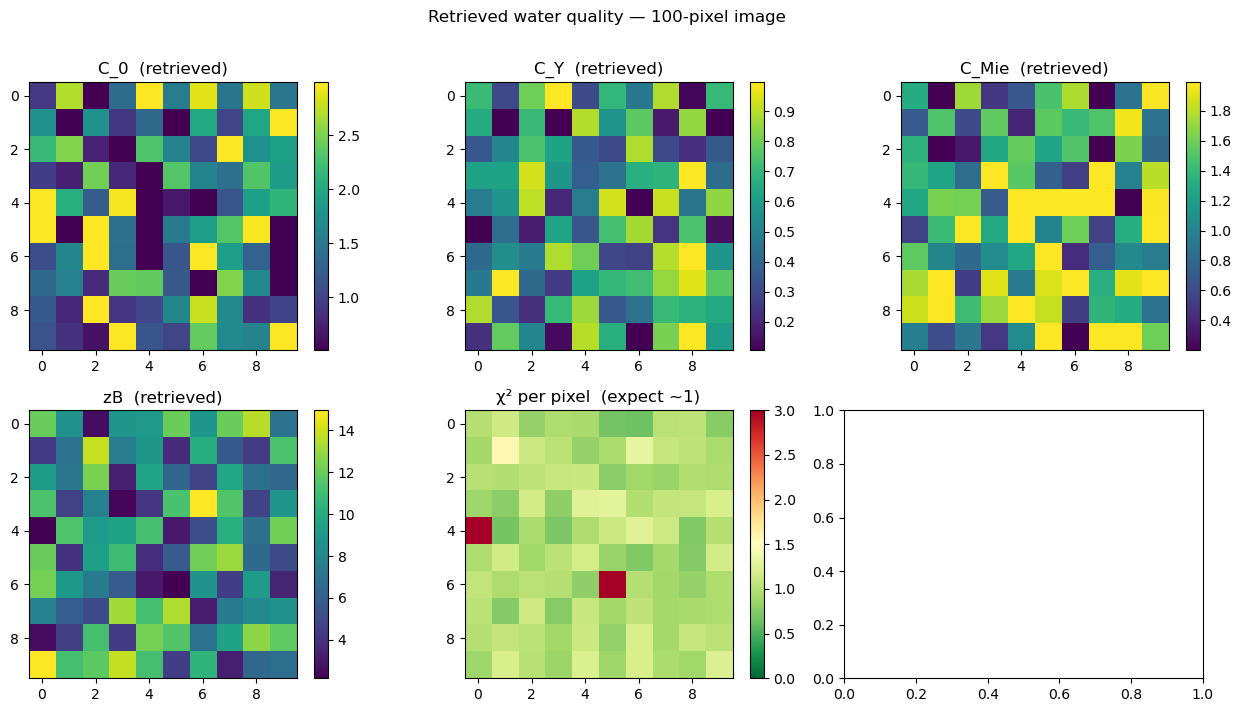

C_0       RMSE = 1.1759
C_Y       RMSE = 0.0946
C_Mie     RMSE = 0.5675
zB        RMSE = 1.2104


In [9]:
import time

# --- Simulate a 10×10 image with spatially varying water quality ------------
n_rows, n_cols = 10, 10
n_pixels = n_rows * n_cols
rng = np.random.default_rng(0)

# --- Build inversion setup FIRST (for model-consistent simulation) ----------
setup = oe_engine.build_inversion(params_s2, f_vec_w, sigma_a_s2)
print(f'Free parameters ({len(setup.fit_names)}): {setup.fit_names}')

# Vary only FREE parameters — using setup.f_fit means fixed params (e.g. C_X)
# are already embedded in the closure, so simulation matches the inversion exactly.
param_ranges = {'C_0': (0.5, 3.0), 'C_Y': (0.1, 1.0), 'C_X': (0.5, 6.0),
                'C_Mie': (0.2, 2.0), 'zB': (2.0, 15.0)}

x_true_batch = np.stack([
    rng.uniform(*param_ranges[n], n_pixels) for n in setup.fit_names
], axis=1)   # shape (n_pixels, n_fit)

truth_per_param = dict(zip(setup.fit_names, x_true_batch.T))
zB_img = truth_per_param.get('zB')   # for per-pixel prior cell below

# Simulate through setup.f_fit (fixed params already embedded)
Rrs_clean = np.stack([
    np.array(setup.f_fit(jnp.array(x_true_batch[k])))
    for k in range(n_pixels)
])
Rrs_image = Rrs_clean + noise_std * rng.standard_normal(Rrs_clean.shape)

print(f'Image shape: {Rrs_image.shape}  (n_pixels x n_bands)')

# JIT-compile and run (compilation included in the first call)
invert_jit = jax.jit(
    lambda pixels: oe_engine.invert_pixels(
        setup.f_fit, pixels, noise_std, setup.x_a, setup.S_a_inv, n_iter=10, lm_damping=0.1
    )
)
t0 = time.perf_counter()
results_img = invert_jit(jnp.array(Rrs_image))
results_img.x_hat.block_until_ready()
t1 = time.perf_counter()
print(f'Inverted {n_pixels} pixels in {(t1-t0)*1000:.1f} ms  '
      f'({(t1-t0)/n_pixels*1000:.2f} ms/pixel)')

# --- Reshape results to image grid and plot ---------------------------------
x_hat_img = np.array(results_img.x_hat).reshape(n_rows, n_cols, len(setup.fit_names))
chi2_img  = np.array(results_img.chi2).reshape(n_rows, n_cols)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
param_labels = setup.fit_names
truth_maps   = x_true_batch.reshape(n_rows, n_cols, len(setup.fit_names))

for i, (ax, name) in enumerate(zip(axes.flat, param_labels)):
    vmin = truth_maps[:, :, i].min()
    vmax = truth_maps[:, :, i].max()
    im = ax.imshow(x_hat_img[:, :, i], vmin=vmin, vmax=vmax,
                   cmap='viridis', origin='upper')
    ax.set_title(f'{name}  (retrieved)')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Last panel: chi²
ax = axes.flat[len(param_labels)]
im = ax.imshow(chi2_img, cmap='RdYlGn_r', vmin=0, vmax=3, origin='upper')
ax.set_title('χ² per pixel  (expect ~1)')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'Retrieved water quality — {n_pixels}-pixel image', y=1.01)
plt.tight_layout()
plt.show()

# Quick RMSE check
for i, name in enumerate(setup.fit_names):
    rmse = np.sqrt(np.nanmean((x_hat_img[:, :, i] - truth_maps[:, :, i])**2))
    print(f'{name:<8}  RMSE = {rmse:.4f}')

### Per-pixel priors — using a bathymetry map for zB

When you have an auxiliary data source (e.g. a bathymetry chart, a chlorophyll climatology, or a previous retrieval pass), you can encode it as a **per-pixel prior mean** by passing a 2-D `x_a` array of shape `(n_pixels, n_params)`.  Pair it with a tighter `sigma_a(zB)` to tell the solver how much to trust the map.

The prior covariance can also vary per pixel — pass a 3-D `S_a_inv` of shape `(n_pixels, n_params, n_params)` if your map confidence varies spatially (e.g. shallower pixels from a high-resolution survey get tighter σ, deeper pixels get looser σ).

Inverted 100 pixels (per-pixel zB prior) in 30223.6 ms


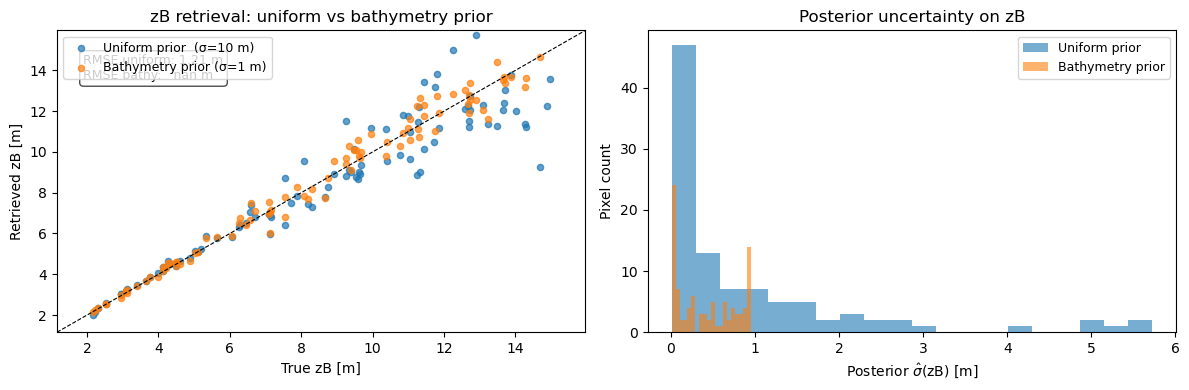

In [10]:
# names_s2 = ['C_0', 'C_Y', 'C_X', 'C_Mie', 'zB']
zB_idx = setup.fit_names.index('zB')

# --- Simulate a bathymetry map (noisy truth + some bias) --------------------
# In practice this comes from a chart, sonar survey, or previous retrieval.
bathy_noise = rng.standard_normal(n_pixels) * 1.0   # ±1 m map uncertainty
zB_map = zB_img + bathy_noise                        # noisy but unbiased depth map

# --- Build per-pixel prior mean ---------------------------------------------
# Start from the global prior mean, then override the zB column with the map.
x_a_global = setup.x_a   # already built by build_inversion() above
x_a_perpixel = jnp.tile(x_a_global, (n_pixels, 1))           # (n_pixels, n_params)
x_a_perpixel = x_a_perpixel.at[:, zB_idx].set(jnp.array(zB_map))

# --- Build per-pixel inverse prior covariance -------------------------------
# Tight sigma for zB (trust the map); same as before for everything else.
sigma_a_with_bathy = {**sigma_a_s2, 'zB': 1.0}   # 1 m uncertainty from map
sigma_a_vec = jnp.array([sigma_a_with_bathy[n] for n in setup.fit_names])
S_a_inv_global = jnp.diag(1.0 / sigma_a_vec**2)   # same for all pixels here
# (pass a 3-D array if confidence varies per pixel)

# --- Invert with per-pixel priors -------------------------------------------
invert_bathy_jit = jax.jit(
    lambda pixels, xa: oe_engine.invert_pixels(
        setup.f_fit, pixels, noise_std, xa, S_a_inv_global, n_iter=10, lm_damping=0.1
    )
)
_ = invert_bathy_jit(jnp.array(Rrs_image[:2]), x_a_perpixel[:2])   # compile

t0 = time.perf_counter()
results_bathy = invert_bathy_jit(jnp.array(Rrs_image), x_a_perpixel)
results_bathy.x_hat.block_until_ready()
t1 = time.perf_counter()
print(f'Inverted {n_pixels} pixels (per-pixel zB prior) in {(t1-t0)*1000:.1f} ms')

# --- Compare zB retrieval: uniform prior vs bathymetry prior ----------------
zB_uniform = np.array(results_img.x_hat)[:, zB_idx]
zB_bathy   = np.array(results_bathy.x_hat)[:, zB_idx]
zB_true    = zB_img

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
lims = (zB_true.min() - 1, zB_true.max() + 1)
ax.scatter(zB_true, zB_uniform, s=20, alpha=0.7, label='Uniform prior  (σ=10 m)')
ax.scatter(zB_true, zB_bathy,   s=20, alpha=0.7, label='Bathymetry prior (σ=1 m)')
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True zB [m]')
ax.set_ylabel('Retrieved zB [m]')
ax.set_title('zB retrieval: uniform vs bathymetry prior')
ax.legend(fontsize=9)

rmse_uniform = np.sqrt(np.mean((zB_uniform - zB_true)**2))
rmse_bathy   = np.sqrt(np.mean((zB_bathy   - zB_true)**2))
ax.text(0.05, 0.92, f'RMSE uniform: {rmse_uniform:.2f} m\nRMSE bathy:   {rmse_bathy:.2f} m',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

ax = axes[1]
sigma_zB_uniform = np.sqrt(np.array(results_img.S_hat)[:, zB_idx, zB_idx])
sigma_zB_bathy   = np.sqrt(np.array(results_bathy.S_hat)[:, zB_idx, zB_idx])
ax.hist(sigma_zB_uniform, bins=20, alpha=0.6, label='Uniform prior')
ax.hist(sigma_zB_bathy,   bins=20, alpha=0.6, label='Bathymetry prior')
ax.set_xlabel(r'Posterior $\hat{\sigma}$(zB) [m]')
ax.set_ylabel('Pixel count')
ax.set_title('Posterior uncertainty on zB')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()